## Hypothesis Tests Part → Third of the Pipeline (**Report + Decision Layer**)

In **Leg 3**, we stop building signals and stop calculating metrics.  
This notebook exists for one purpose:

> **Turn the already-computed results into a clear, human-readable report and decision.**

So Leg 3 is the “presentation + judgment” layer of the project.


### **Main Goal**

Leg 3 reads only the **exported JSON outputs** from **Leg 2 (`eval_metrics.ipynb`)**, then:

- **visualizes** the results (tables + plots)
- **summarizes** what the numbers mean
- **writes a clear decision** for each hypothesis (H1–H5)

This is where we answer, in plain language:

- “Did we find evidence of an edge?”
- “How strong is it, and how reliable is it?”
- “Do we reject the null hypothesis, or not?”


### **Strict Rules of this notebook (no mixing responsibilities)**

To keep the pipeline clean and reproducible, Leg 3 follows strict boundaries:

#### **1) We do NOT rebuild events or predictions**
That is the job of **Leg 1 (Event Factory)**.  
So in Leg 3:
- no new `is_Hx` logic
- no new `pred_Hx_*` logic
- no feature engineering


#### **2) We do NOT recompute metrics**
That is the job of **Leg 2 (Metrics Engine)**.  
So in Leg 3:
- no recalculating hit-rate
- no recalculating p-values
- no re-running evaluation loops

Leg 3 assumes the metrics are already correct and final.


### **What we DO in Leg 3 (the only responsibilities)**

Leg 3 does exactly four actions:

#### **(a) Load saved JSON metric files**
We load the exported outputs such as:

- `H1_metrics.json`
- `H2_metrics.json`
- ...
- `H5_metrics.json`

These JSON files are the “single source of truth” for performance results.


#### **(b) Standardize outputs into plot-ready tables**
Different hypotheses may return slightly different metric keys.  
So we convert JSON dictionaries into clean, consistent structures like:

- one table per hypothesis
- same column naming style
- ready for plotting and comparison


#### **(c) Plot and visualize**
We produce viewer-friendly figures such as:

- hit-rate comparisons (15 vs 30 minutes)
- p-values and confidence intervals
- effect size (returns) distributions
- subgroup comparisons (if present)
- order-group tables (for H5)

The goal is: **make the results readable in 10 seconds.**


#### **(d) Write decisions**
For each hypothesis (H1–H5), we produce a clear decision statement:

- **Reject H0** or **Fail to reject H0**
- plus a short justification using the key metrics:
  - sample size
  - hit-rate
  - p-value
  - effect size
  - robustness checks (if included)

So the output is not just numbers — it is a final conclusion.

---


## The 3-Leg Pipeline (How the whole system is organized)

### **Leg 1 — prediction.ipynb (Event Factory)** 
**Goal:** Create new columns that mark **where** each hypothesis applies and **what the rule predicts** (if applicable).

- We do **NOT** prove anything here.
- We do **NOT** compute p-values or draw conclusions here.
- We only build:
  - **event masks** (which rows are “in the hypothesis world”)
  - **baseline rule predictions** (optional for some hypotheses)

**Output pattern (typical):**
- `is_Hx` → 0/1 mask for “this row is a valid event for Hx”
- `pred_Hx_*` → rule-based prediction (if the hypothesis is directional)
- additional tags (if the hypothesis is grouping / moderator)

Some hypotheses are already fully defined by existing features and labels → they may pass through this leg with minimal work.

### **Leg 2 — eval_metrics.ipynb (Metrics Engine)** 
**Goal:** Given an event definition and predictions, compute all **evaluation metrics** consistently.

Think of this as a reusable “calculator”:

- Input: **(mask, y_true, y_pred)**  
- Output: metrics such as:
  - **hit-rate**
  - **precision / recall / F1** (for rule predictions)
  - **p-value** (example: test `hit-rate > 0.5`)
  - **effect size** (example: signed returns, distance reduction)
  - reusable slice logic (IB width, gap alignment, etc.)

### **Leg 3 — hypothesis_tests.ipynb (Report + Decision Layer)** --> WE ARE IN HERE !!!
**Goal:** Present results in a clean, viewer-friendly form and state decisions clearly.

This is where we:
- show tables/figures
- explain measurement choices (especially for “reversion” type ideas)
- decide:
  - **Reject null hypothesis** or
  - **Fail to reject null hypothesis**
based on the metrics and p-values from Leg 2.

---

### **What Leg 3 expects as inputs**

Leg 3 does **not** read the full dataframe and does **not** recompute any metrics.  
It only reads the **saved JSON metric outputs** created by **Leg 2 (`eval_metrics.ipynb`)**.

So before running Leg 3, we expect the following files to already exist:

- **`H1_metrics.json`**
- **`H2_metrics.json`**
- **`H3_metrics.json`**
- **`H4_metrics.json`**
- **`H5_metrics.json`**

Each JSON file is the “final scorecard” for that hypothesis.


### **What information we expect inside each JSON**

Different hypotheses may produce slightly different metric fields, but we assume each JSON contains as many of the following as applicable:

#### **1) Sample size / coverage (how much data was evaluated)**
Leg 3 needs to know whether the result is based on a strong sample or just a few rows.

Typical fields include:

- **`N`** (number of evaluated rows)
- and/or **`base_rows`** (size of the base universe before filtering)
- and/or **`coverage`** (how often the rule produces a prediction vs abstains)

These values answer:
> “How many valid events did we actually test, and how much did the rule speak?”


#### **2) Classification metrics (directional performance)**
For hypotheses that produce direction predictions (like H2, H4, and sometimes H1/H3), we expect metrics such as:

- **hit-rate / accuracy**
- **precision**
- **recall**
- **F1 score**

These answer:
> “When the hypothesis predicts up/down, how often is it correct, and how balanced are its errors?”


#### **3) Statistical significance outputs (p-values, hypothesis tests)**
Leg 3 needs the “is this better than chance?” evidence.

So we expect values like:

- **p-value** (often from a binomial test style: testing whether hit-rate > 0.5)

These answer:
> “Is the observed performance likely to be real, or could it be random noise?”


#### **4) Return / effect-size summaries (economic meaning)**
Even if something is statistically significant, it may be economically meaningless.

So when available, we expect return-based summaries such as:

- mean / median **signed returns**
- possibly return distributions or summary percentiles

These answer:
> “If the signal is correct, does it deliver meaningful move size (edge), not just a tiny statistical win?”


#### **5) Day-wise uncertainty (bootstrap-by-day confidence intervals)**
Minute bars inside a day are not fully independent, so we prefer uncertainty estimates that work **by day**.

When available, we expect:

- **bootstrap-by-day confidence intervals**  
  (for hit-rate, p_up(order), effect size, etc.)

These answer:
> “Is this effect stable across days, or is it driven by a few lucky days?”

In [26]:
import pandas as pd
import numpy as np
from pathlib import Path
import json 
import matplotlib

## **H1**

Leg 3 is the place where we stop “building” and start “judging”.  
For H1, that means we take the results already computed in Leg 2 and answer:

> **Does the evidence actually support H1’s claim, in the exact situations H1 describes?**


### **Context: What H1 is claiming (in plain language)**

H1 is **not** a vague statement like “markets revert sometimes.”

H1 is a specific, testable claim:

> When price is **between two AVWAPs**, those AVWAPs are **very close**,  
> and their slopes **disagree** (one drifting up, the other drifting down),  
> then the next **15–30 minutes** are **more likely than random (>50%)**  
> to drift in the direction H1 predicts.

So in Leg 3 we do **not** try to recreate the setup.  
We only check:

- **What was measured in Leg 2**
- **Whether it supports the claim**
- **Where (which regime, which horizon) the effect appears**

And the first step is always: **visualize**.


### **(a) Input (What does Leg 3 need to start H1?)**

Leg 3 does **not** read the full CSV and does **not** recompute the H1 event logic.

For H1, Leg 3 expects exactly one file to already exist:

- **`H1_metrics.json`**

This file is produced by **Leg 2 (`eval_metrics.ipynb`)** after evaluating:

- the H1 event universe (**mask**)
- `y_true = dir15 / dir30`
- `y_pred = pred_H1_dir15 / pred_H1_dir30`
- plus all derived metrics (hit-rate, p-values, returns, etc.)

In Leg 3, we treat this JSON as H1’s frozen scoreboard:

> **“Given the exact H1 definition and evaluation method, what did we measure?”**


### **(b) Structure of H1 results (How we organize what we read)**

Because H1 is a **regime-dependent** idea (“close + disagreeing AVWAPs”), we do not want one single number.

We want to see whether the effect changes by:

#### **1) Horizon (H1 claims 15–30 minutes)**
- **15 minutes**
- **30 minutes**

#### **2) Regime segment (market can behave differently)**
- **overall**
- **narrow** (tight first-hour range regime)
- **wide** (expanded first-hour range regime)

So in Leg 3, the core reading structure is always:

> **overall vs narrow vs wide**, separately for **15** and **30** minutes.


### **(c) What we visualize first (H1 plots + why they matter)**

In Leg 3, we do not “read a JSON and instantly conclude.”  
We do this sequence:

> **Table → plot → interpretation → decision**

Below are the main plots and what each one answers.


#### **1) Drift vs coin flip (the core H1 claim)**
For each **segment × horizon**, plot:

- **hit-rate (accuracy)**  
with a reference line at **0.50**

This answers:
> “In the exact H1 setup, does the prediction beat randomness?”

If hit-rate is not above 0.50, H1’s “more likely than not” claim is not supported.


#### **2) Drift vs naive baseline (is this real, or just class imbalance?)**
Sometimes the data slice itself has more “up” than “down”.

So we plot side-by-side:

- **hit-rate**
- **majority_baseline_acc** (always predict the majority class)

This answers:
> “Is H1 better than the dumb baseline, or does it only look good because the slice is biased?”

A real edge should ideally beat **both**:
- 0.50
- majority baseline


#### **3) Error shape (what kind of ‘wrong’ is H1?)**
A hypothesis can have the same accuracy but very different failure patterns.

So we visualize:

- **precision**
- **recall**
- **F1**

by **segment × horizon**

This answers:
> “Is H1 balanced, or does it behave like a one-sided caller (good at one class, bad at the other)?”


#### **4) Economic meaning (is the ‘drift’ tradable, or tiny?)**
H1 is about movement, not just being “right” by 0.1%.

So we visualize:

- **mean_signed_return**
- **median_signed_return**

by **segment × horizon**

This answers:
> “Even if accuracy improves, do returns show meaningful edge?”

If returns are near zero (or inconsistent), the signal may not be useful even if hit-rate is slightly above chance.


#### **5) Day-wise stability (is it consistent across days?)**
Intraday minutes inside the same day are dependent, so we prefer day-aware uncertainty.

If the JSON provides bootstrap-by-day results, we visualize confidence intervals for:

- hit-rate
- F1
- mean_signed_return

using (2.5 / 50 / 97.5) percentiles.

This answers:
> “Is H1 stable across many days, or driven by a few lucky days?”

**Practical stability rule-of-thumb in Leg 3:**
- If the hit-rate CI lower bound is **≤ 0.50**, chance-beating is not stable.
- If the return CI crosses **0**, economic edge is not stable.


### **(d) Only after plots: the H1 decision checklist (how we conclude)**

Once we’ve seen the visuals, we summarize in H1 language:

1. **Does any slice beat 0.50?** (15 and/or 30)
2. **Does it also beat the majority baseline?**
3. **Where is the effect strongest?**
   - concentrated in **narrow**? → “tight-regime phenomenon”
   - concentrated in **wide**? → “needs expansion regime”
4. **Do returns agree with direction success?**
   - hit-rate up but returns flat → suspicious / not tradable
5. **Do bootstrap intervals support day-stability?**
   - CI crosses 0.50 or 0 return → not stable enough


### **Important H1 diagnostic (flagging a common failure mode)**

Leg 3 will explicitly watch for this pattern:

- If hit-rate is **consistently below 0.50** across slices,  
  it often means the direction mapping is inverted (prediction sign mismatch).

Example:
- the rule says “predict up”, but your `dir15/dir30` encoding might interpret direction the opposite way, or the “toward mid” mapping may be flipped.

Leg 3 will **not fix** this (fixing belongs to Leg 1/2),  
but it will **flag it clearly** once the plots confirm it.



In [34]:
# Inputting our .json file into the system

PROJECT_ROOT = Path("..").resolve()
JSONFILE = PROJECT_ROOT / "reports"

METRICS_FILE = JSONFILE / "H1_metrics.json"

# Load JSON into a Python dict
with open(METRICS_FILE, "r", encoding="utf-8") as f:
    h1 = json.load(f)

# Quick sanity peek
print("Loaded keys:", list(h1.keys()))
print("Example block (overall_15):", h1.get("overall_15", None))

Loaded keys: ['overall_15', 'overall_30', 'narrow_15', 'narrow_30', 'wide_15', 'wide_30', 'bootstrap_overall_15', 'bootstrap_overall_30']
Example block (overall_15): {'N': 326, 'k_correct': 135, 'hit_rate': 0.41411042944785276, 'tp': 68, 'fp': 111, 'fn': 80, 'tn': 67, 'precision': 0.37988826815642457, 'recall': 0.4594594594594595, 'f1': 0.41590214067278286, 'pval_greater(>p0)': 0.9992225940463264, 'pval_less(<p0)': 0.0011340343275836327, 'pval_two_sided': 0.0022680686551672653, 'mean_signed_return': -0.0002096181345698247, 'median_signed_return': -0.00010388184773285, 'y_true_up_rate': 0.4539877300613497, 'majority_baseline_acc': 0.5460122699386503}


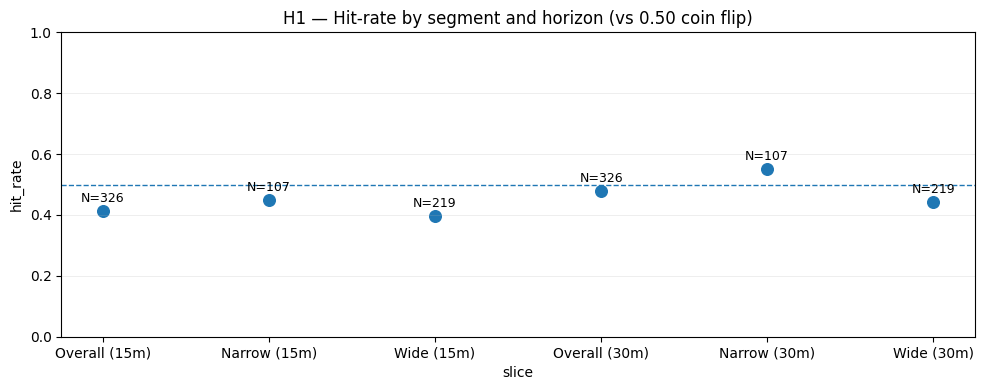

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# H1 — Plot #1
# Drift vs coin flip (0.50 line) — disconnected dot plot
# ==========================
# Assumes: h1 is already loaded (dict)

slices = ["overall_15", "narrow_15", "wide_15", "overall_30", "narrow_30", "wide_30"]

# Build a small plot-ready table
rows = []
for k in slices:
    if k not in h1:
        raise KeyError(f"Missing key in h1 JSON: {k}")
    rows.append({
        "slice": k,
        "hit_rate": float(h1[k].get("hit_rate", float("nan"))),
        "N": int(h1[k].get("N", 0)),
    })

df_plot = pd.DataFrame(rows)

# Nice ordering + labels
df_plot["segment"] = df_plot["slice"].str.split("_").str[0]
df_plot["horizon"] = df_plot["slice"].str.split("_").str[1].astype(int)
df_plot["label"] = df_plot["segment"].str.capitalize() + " (" + df_plot["horizon"].astype(str) + "m)"

# explicit order so sort is deterministic
seg_order = {"overall": 0, "narrow": 1, "wide": 2}
df_plot["seg_rank"] = df_plot["segment"].map(seg_order).fillna(99).astype(int)
df_plot = df_plot.sort_values(["horizon", "seg_rank"]).reset_index(drop=True)

# Plot (single figure) — disconnected points
fig, ax = plt.subplots(figsize=(10, 4))

x = list(range(len(df_plot)))
y = df_plot["hit_rate"].values

ax.scatter(x, y, s=70)  # disconnected dot plot
ax.axhline(0.50, linewidth=1, linestyle="--")  # coin flip reference

ax.set_xticks(x)
ax.set_xticklabels(df_plot["label"].values)
ax.set_ylim(0, 1)
ax.set_title("H1 — Hit-rate by segment and horizon (vs 0.50 coin flip)")
ax.set_ylabel("hit_rate")
ax.set_xlabel("slice")

# annotate N above points (clamped so it won't go off the chart top)
for i, (hr, n) in enumerate(zip(df_plot["hit_rate"], df_plot["N"])):
    y_text = min(hr + 0.02, 0.98)
    ax.text(i, y_text, f"N={n}", ha="center", va="bottom", fontsize=9)

# optional: light grid for readability
ax.grid(True, axis="y", linewidth=0.6, alpha=0.25)

fig.tight_layout()
plt.show()


In [29]:

import json
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown


# 1) Pull the exact values used in Plot #1
slices = ["overall_15", "narrow_15", "wide_15", "overall_30", "narrow_30", "wide_30"]
label_map = {
    "overall_15": "Overall (15m)",
    "narrow_15":  "Narrow (15m)",
    "wide_15":    "Wide (15m)",
    "overall_30": "Overall (30m)",
    "narrow_30":  "Narrow (30m)",
    "wide_30":    "Wide (30m)",
}

rows = []
for k in slices:
    b = h1[k]
    rows.append({
        "slice": label_map[k],
        "N": int(b["N"]),
        "k_correct": int(b["k_correct"]),
        "hit_rate": float(b["hit_rate"]),
        "segment": k.split("_")[0],
        "horizon": int(k.split("_")[1]),
    })

df = pd.DataFrame(rows).sort_values(["horizon", "segment"])
df["delta_vs_50"] = df["hit_rate"] - 0.50

best = df.sort_values("hit_rate", ascending=False).iloc[0]
worst = df.sort_values("hit_rate", ascending=True).iloc[0]

count_above = int((df["hit_rate"] > 0.50).sum())
count_below = int((df["hit_rate"] < 0.50).sum())

def pct(x): 
    return f"{100*x:.1f}%"

def fmt_delta(d):
    sign = "+" if d >= 0 else ""
    return f"{sign}{d:.3f} ({sign}{100*d:.1f}pp)"

md = f"""
## H1 — Plot #1 (Hit-rate vs 0.50 coin flip)

### What this plot is checking
H1 claims the direction should be **more likely than not** in the H1 setup.  
So this plot asks a single question per slice:

> **Is hit-rate above 0.50, or is it at/below coin flip?**

### What we see in the dots
- **{count_above}/6** slices are **above 0.50**, and **{count_below}/6** are **below 0.50**.
- Best dot: **{best['slice']}** → hit-rate **{best['hit_rate']:.3f} ({pct(best['hit_rate'])})**, Δ vs 0.50 = **{fmt_delta(best['delta_vs_50'])}**, N={int(best['N'])}.
- Worst dot: **{worst['slice']}** → hit-rate **{worst['hit_rate']:.3f} ({pct(worst['hit_rate'])})**, Δ vs 0.50 = **{fmt_delta(worst['delta_vs_50'])}**, N={int(worst['N'])}.

### What this means for H1 (based on Plot #1 only)
Because most dots sit **below** the 0.50 line, this plot alone does **not** show the “more-than-50%” behavior consistently across slices.  
This plot is descriptive only; statistical certainty and economic meaning are handled in the later plots.
""".strip()

display(Markdown(md))

# Optional: show the exact table behind the plot
# display(df[["slice","N","k_correct","hit_rate","delta_vs_50"]])


## H1 — Plot #1 (Hit-rate vs 0.50 coin flip)

### What this plot is checking
H1 claims the direction should be **more likely than not** in the H1 setup.  
So this plot asks a single question per slice:

> **Is hit-rate above 0.50, or is it at/below coin flip?**

### What we see in the dots
- **1/6** slices are **above 0.50**, and **5/6** are **below 0.50**.
- Best dot: **Narrow (30m)** → hit-rate **0.551 (55.1%)**, Δ vs 0.50 = **+0.051 (+5.1pp)**, N=107.
- Worst dot: **Wide (15m)** → hit-rate **0.397 (39.7%)**, Δ vs 0.50 = **-0.103 (-10.3pp)**, N=219.

### What this means for H1 (based on Plot #1 only)
Because most dots sit **below** the 0.50 line, this plot alone does **not** show the “more-than-50%” behavior consistently across slices.  
This plot is descriptive only; statistical certainty and economic meaning are handled in the later plots.

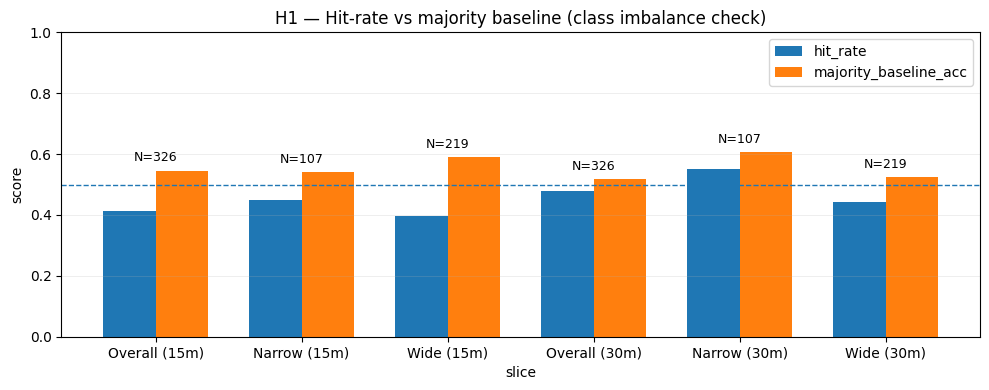

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# H1 — Plot #2
# Drift vs naive baseline (class imbalance check)
# hit_rate vs majority_baseline_acc (side-by-side)
# ==========================

slices = ["overall_15", "narrow_15", "wide_15", "overall_30", "narrow_30", "wide_30"]

rows = []
for k in slices:
    if k not in h1:
        raise KeyError(f"Missing key in h1 JSON: {k}")
    block = h1[k]
    rows.append({
        "slice": k,
        "hit_rate": float(block.get("hit_rate", float("nan"))),
        "majority_baseline_acc": float(block.get("majority_baseline_acc", float("nan"))),
        "N": int(block.get("N", 0)),
    })

df_plot = pd.DataFrame(rows)

# labels + deterministic ordering
df_plot["segment"] = df_plot["slice"].str.split("_").str[0]
df_plot["horizon"] = df_plot["slice"].str.split("_").str[1].astype(int)
df_plot["label"] = df_plot["segment"].str.capitalize() + " (" + df_plot["horizon"].astype(str) + "m)"

seg_order = {"overall": 0, "narrow": 1, "wide": 2}
df_plot["seg_rank"] = df_plot["segment"].map(seg_order).fillna(99).astype(int)
df_plot = df_plot.sort_values(["horizon", "seg_rank"]).reset_index(drop=True)

# --- plot (single figure) ---
fig, ax = plt.subplots(figsize=(10, 4))

x = list(range(len(df_plot)))
w = 0.36  # bar width

ax.bar([i - w/2 for i in x], df_plot["hit_rate"].values, width=w, label="hit_rate")
ax.bar([i + w/2 for i in x], df_plot["majority_baseline_acc"].values, width=w, label="majority_baseline_acc")

# optional coin flip reference
ax.axhline(0.50, linewidth=1, linestyle="--")

ax.set_xticks(x)
ax.set_xticklabels(df_plot["label"].values)
ax.set_ylim(0, 1)
ax.set_title("H1 — Hit-rate vs majority baseline (class imbalance check)")
ax.set_ylabel("score")
ax.set_xlabel("slice")
ax.legend()

# annotate N above the taller bar in each pair
for i, (hr, mb, n) in enumerate(zip(df_plot["hit_rate"], df_plot["majority_baseline_acc"], df_plot["N"])):
    y_top = max(hr, mb)
    y_text = min(y_top + 0.02, 0.98)
    ax.text(i, y_text, f"N={n}", ha="center", va="bottom", fontsize=9)

ax.grid(True, axis="y", linewidth=0.6, alpha=0.25)
fig.tight_layout()
plt.show()


In [31]:

import json
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

# ==========================
# H1 — Plot #2 interpretation text (EN, beginner-friendly)
# ONLY: hit_rate vs majority_baseline_acc across 6 slices
# Uses only: N, hit_rate, majority_baseline_acc (and 0.50 reference line)
# ==========================

# 1) Pull exact values used in Plot #2
slices = ["overall_15", "narrow_15", "wide_15", "overall_30", "narrow_30", "wide_30"]
label_map = {
    "overall_15": "Overall (15m)",
    "narrow_15":  "Narrow (15m)",
    "wide_15":    "Wide (15m)",
    "overall_30": "Overall (30m)",
    "narrow_30":  "Narrow (30m)",
    "wide_30":    "Wide (30m)",
}

rows = []
for k in slices:
    b = h1[k]
    rows.append({
        "slice": label_map[k],
        "N": int(b["N"]),
        "hit_rate": float(b["hit_rate"]),
        "majority_baseline_acc": float(b["majority_baseline_acc"]),
        "segment": k.split("_")[0],
        "horizon": int(k.split("_")[1]),
    })

df = pd.DataFrame(rows).sort_values(["horizon", "segment"]).reset_index(drop=True)

# 2) Comparisons
df["gap_vs_majority"] = df["hit_rate"] - df["majority_baseline_acc"]
wins = int((df["gap_vs_majority"] > 0).sum())
losses = int((df["gap_vs_majority"] < 0).sum())
ties = int((df["gap_vs_majority"] == 0).sum())

best_gap = df.sort_values("gap_vs_majority", ascending=False).iloc[0]
worst_gap = df.sort_values("gap_vs_majority", ascending=True).iloc[0]

# 3) Build a tight, plot-only interpretation (with a clear baseline definition)
def pct(x): 
    return f"{100*x:.1f}%"

def fmt_pp(x):
    sign = "+" if x >= 0 else ""
    return f"{sign}{100*x:.1f}pp"

md = f"""
## H1 — Plot #2 (Hit-rate vs Majority Baseline)

### Why this plot exists
H1 claims it predicts direction better than randomness **in the H1 setup**.  
But even if a rule has *some* accuracy, it may still be useless if the data slice itself is biased.

So this plot asks a sharper question than “is hit-rate above 0.50?”:

> **Does H1 beat a very simple baseline that ignores H1 entirely?**

### What “majority baseline” means
For each slice (e.g., *Overall (15m)*), we look at the true labels in that slice:
- If the slice contains **more UP than DOWN**, the majority class is **UP**.
- A “majority baseline” strategy is: **always predict the majority class** (always UP in that example).

That baseline accuracy is what you would get by being “lazy but consistent”:
- You do **not** use AVWAPs,
- You do **not** use the H1 rule,
- You just guess the most common outcome in that slice.

So in this chart:
- **Blue bar** = H1 hit-rate (how often H1 was correct)
- **Orange bar** = majority-baseline accuracy (how often the “always majority” guess would be correct)

### What we are comparing (the core of this chart)
> **Blue vs Orange**: does H1 add value beyond class imbalance?

- If **blue > orange** → H1 adds information beyond “just guess the dominant direction”.
- If **blue < orange** → H1 is worse than a naive guess for that slice.

### What we see
- Across the 6 slices, H1 beats the majority baseline in **{wins}/6** slices (ties: {ties}, loses: {losses}).

Best relative case:
- **{best_gap['slice']}** → hit-rate **{best_gap['hit_rate']:.3f} ({pct(best_gap['hit_rate'])})** vs baseline **{best_gap['majority_baseline_acc']:.3f} ({pct(best_gap['majority_baseline_acc'])})**  
- Gap (blue − orange) = **{fmt_pp(best_gap['gap_vs_majority'])}**, N={int(best_gap['N'])}

Worst relative case:
- **{worst_gap['slice']}** → hit-rate **{worst_gap['hit_rate']:.3f} ({pct(worst_gap['hit_rate'])})** vs baseline **{worst_gap['majority_baseline_acc']:.3f} ({pct(worst_gap['majority_baseline_acc'])})**  
- Gap (blue − orange) = **{fmt_pp(worst_gap['gap_vs_majority'])}**, N={int(worst_gap['N'])}

### What this means for H1 (based on Plot #2 only)
In most slices, the orange bar is above the blue bar. That means:
- The slice is directionally imbalanced, and
- A naive “always guess the majority direction” approach would outperform H1 in that slice.

So, **as shown by this chart**, H1 generally does **not** outperform the simplest imbalance-aware baseline.
""".strip()

display(Markdown(md))


## H1 — Plot #2 (Hit-rate vs Majority Baseline)

### Why this plot exists
H1 claims it predicts direction better than randomness **in the H1 setup**.  
But even if a rule has *some* accuracy, it may still be useless if the data slice itself is biased.

So this plot asks a sharper question than “is hit-rate above 0.50?”:

> **Does H1 beat a very simple baseline that ignores H1 entirely?**

### What “majority baseline” means
For each slice (e.g., *Overall (15m)*), we look at the true labels in that slice:
- If the slice contains **more UP than DOWN**, the majority class is **UP**.
- A “majority baseline” strategy is: **always predict the majority class** (always UP in that example).

That baseline accuracy is what you would get by being “lazy but consistent”:
- You do **not** use AVWAPs,
- You do **not** use the H1 rule,
- You just guess the most common outcome in that slice.

So in this chart:
- **Blue bar** = H1 hit-rate (how often H1 was correct)
- **Orange bar** = majority-baseline accuracy (how often the “always majority” guess would be correct)

### What we are comparing (the core of this chart)
> **Blue vs Orange**: does H1 add value beyond class imbalance?

- If **blue > orange** → H1 adds information beyond “just guess the dominant direction”.
- If **blue < orange** → H1 is worse than a naive guess for that slice.

### What we see
- Across the 6 slices, H1 beats the majority baseline in **0/6** slices (ties: 0, loses: 6).

Best relative case:
- **Overall (30m)** → hit-rate **0.479 (47.9%)** vs baseline **0.518 (51.8%)**  
- Gap (blue − orange) = **-4.0pp**, N=326

Worst relative case:
- **Wide (15m)** → hit-rate **0.397 (39.7%)** vs baseline **0.589 (58.9%)**  
- Gap (blue − orange) = **-19.2pp**, N=219

### What this means for H1 (based on Plot #2 only)
In most slices, the orange bar is above the blue bar. That means:
- The slice is directionally imbalanced, and
- A naive “always guess the majority direction” approach would outperform H1 in that slice.

So, **as shown by this chart**, H1 generally does **not** outperform the simplest imbalance-aware baseline.

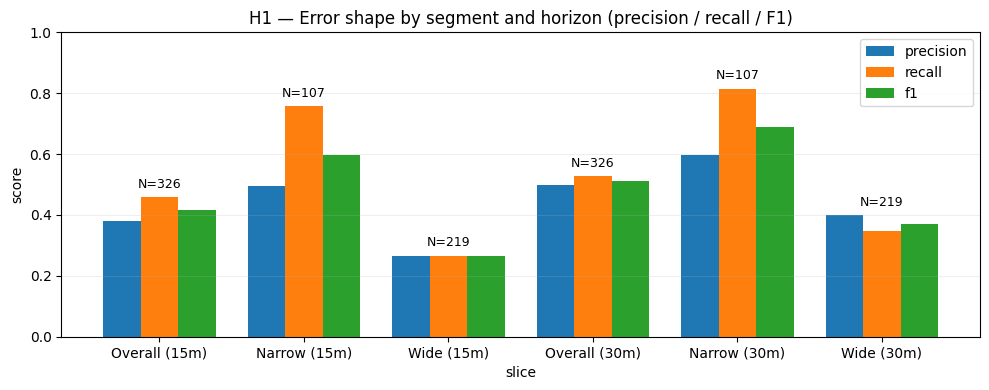

In [32]:
import matplotlib.pyplot as plt

# ==========================
# H1 — Plot #3
# Error shape: precision / recall / F1 (3 series)
# ==========================

slices = ["overall_15", "narrow_15", "wide_15", "overall_30", "narrow_30", "wide_30"]

rows = []
for k in slices:
    if k not in h1:
        raise KeyError(f"Missing key in h1 JSON: {k}")
    block = h1[k]
    rows.append({
        "slice": k,
        "precision": float(block.get("precision", float("nan"))),
        "recall": float(block.get("recall", float("nan"))),
        "f1": float(block.get("f1", float("nan"))),
        "N": int(block.get("N", 0)),
    })

df_plot = pd.DataFrame(rows)

# labels + deterministic ordering
df_plot["segment"] = df_plot["slice"].str.split("_").str[0]
df_plot["horizon"] = df_plot["slice"].str.split("_").str[1].astype(int)
df_plot["label"] = df_plot["segment"].str.capitalize() + " (" + df_plot["horizon"].astype(str) + "m)"

seg_order = {"overall": 0, "narrow": 1, "wide": 2}
df_plot["seg_rank"] = df_plot["segment"].map(seg_order).fillna(99).astype(int)
df_plot = df_plot.sort_values(["horizon", "seg_rank"]).reset_index(drop=True)

# --- plot (single figure) ---
fig, ax = plt.subplots(figsize=(10, 4))

x = list(range(len(df_plot)))
w = 0.26

ax.bar([i - w for i in x], df_plot["precision"].values, width=w, label="precision")
ax.bar(x,                  df_plot["recall"].values,    width=w, label="recall")
ax.bar([i + w for i in x], df_plot["f1"].values,        width=w, label="f1")

ax.set_xticks(x)
ax.set_xticklabels(df_plot["label"].values)
ax.set_ylim(0, 1)
ax.set_title("H1 — Error shape by segment and horizon (precision / recall / F1)")
ax.set_ylabel("score")
ax.set_xlabel("slice")
ax.legend()

# annotate N above the tallest of the 3 bars per slice
for i, (p, r, f, n) in enumerate(zip(df_plot["precision"], df_plot["recall"], df_plot["f1"], df_plot["N"])):
    y_top = max(p, r, f)
    y_text = min(y_top + 0.02, 0.98)
    ax.text(i, y_text, f"N={n}", ha="center", va="bottom", fontsize=9)

ax.grid(True, axis="y", linewidth=0.6, alpha=0.25)
fig.tight_layout()
plt.show()


In [35]:

import json
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

# ==========================
# H1 — Plot #3 interpretation text (EN, beginner-friendly)
# ONLY: precision / recall / F1 across 6 slices
# Uses only: N, precision, recall, f1
# ==========================

# 1) Pull the exact values used in Plot #3
slices = ["overall_15", "narrow_15", "wide_15", "overall_30", "narrow_30", "wide_30"]
label_map = {
    "overall_15": "Overall (15m)",
    "narrow_15":  "Narrow (15m)",
    "wide_15":    "Wide (15m)",
    "overall_30": "Overall (30m)",
    "narrow_30":  "Narrow (30m)",
    "wide_30":    "Wide (30m)",
}

rows = []
for k in slices:
    b = h1[k]
    rows.append({
        "slice": label_map[k],
        "N": int(b["N"]),
        "precision": float(b["precision"]),
        "recall": float(b["recall"]),
        "f1": float(b["f1"]),
        "segment": k.split("_")[0],
        "horizon": int(k.split("_")[1]),
    })

df = pd.DataFrame(rows).sort_values(["horizon", "segment"]).reset_index(drop=True)

# 2) Simple “shape” summaries (still plot-only)
def pct(x): 
    return f"{100*x:.1f}%"

# Identify the most "imbalanced" slice: big gap between precision and recall
df["pr_gap"] = (df["precision"] - df["recall"]).abs()
most_imbal = df.sort_values("pr_gap", ascending=False).iloc[0]

# Best and worst F1 (overall balance)
best_f1 = df.sort_values("f1", ascending=False).iloc[0]
worst_f1 = df.sort_values("f1", ascending=True).iloc[0]

# 3) Build a tight, plot-only interpretation
md = f"""
## H1 — Plot #3 (Precision / Recall / F1)

### Why this plot exists
Hit-rate alone does not tell us *how* H1 is wrong.
This plot describes the **error shape** of H1’s predictions (usually treating **UP = 1** as the “positive” class).

### What the three metrics mean (beginner-friendly)
Think of “UP” as the event we care about detecting.

- **Precision**: *When H1 says “UP”, how often is it actually UP?*  
  (High precision = fewer false “UP” calls.)

- **Recall**: *Out of all true UP cases, how many did H1 successfully call “UP”?*  
  (High recall = H1 catches more of the real UP moves.)

- **F1**: A single balance score that combines precision + recall.  
  (High F1 usually means “not only calling UP often, but calling it correctly”.)

### What we see in this chart
- Best balanced slice (highest F1):
  - **{best_f1['slice']}** → F1 **{best_f1['f1']:.3f} ({pct(best_f1['f1'])})**, precision **{best_f1['precision']:.3f} ({pct(best_f1['precision'])})**, recall **{best_f1['recall']:.3f} ({pct(best_f1['recall'])})**, N={int(best_f1['N'])}
- Weakest balanced slice (lowest F1):
  - **{worst_f1['slice']}** → F1 **{worst_f1['f1']:.3f} ({pct(worst_f1['f1'])})**, precision **{worst_f1['precision']:.3f} ({pct(worst_f1['precision'])})**, recall **{worst_f1['recall']:.3f} ({pct(worst_f1['recall'])})**, N={int(worst_f1['N'])}

### The key “shape” diagnostic (precision vs recall)
The slice with the biggest precision–recall mismatch is:
- **{most_imbal['slice']}** → precision **{most_imbal['precision']:.3f}**, recall **{most_imbal['recall']:.3f}** (gap ≈ {pct(most_imbal['pr_gap'])}), N={int(most_imbal['N'])}

How to read that mismatch (only for this plot):
- If **recall ≫ precision**: H1 calls “UP” a lot and catches many true UPs, but also produces many false UPs.
- If **precision ≫ recall**: H1 is picky—when it says “UP” it’s often right, but it misses many true UPs.

### What this means for H1 (based on Plot #3 only)
This plot does **not** decide whether H1 is profitable or statistically strong.
It only tells us **what kind of mistakes** H1 makes in each slice (more “false UP” vs more “missed UP”),
and which slice looks most/least balanced by F1.
""".strip()

display(Markdown(md))


## H1 — Plot #3 (Precision / Recall / F1)

### Why this plot exists
Hit-rate alone does not tell us *how* H1 is wrong.
This plot describes the **error shape** of H1’s predictions (usually treating **UP = 1** as the “positive” class).

### What the three metrics mean (beginner-friendly)
Think of “UP” as the event we care about detecting.

- **Precision**: *When H1 says “UP”, how often is it actually UP?*  
  (High precision = fewer false “UP” calls.)

- **Recall**: *Out of all true UP cases, how many did H1 successfully call “UP”?*  
  (High recall = H1 catches more of the real UP moves.)

- **F1**: A single balance score that combines precision + recall.  
  (High F1 usually means “not only calling UP often, but calling it correctly”.)

### What we see in this chart
- Best balanced slice (highest F1):
  - **Narrow (30m)** → F1 **0.688 (68.8%)**, precision **0.596 (59.6%)**, recall **0.815 (81.5%)**, N=107
- Weakest balanced slice (lowest F1):
  - **Wide (15m)** → F1 **0.267 (26.7%)**, precision **0.267 (26.7%)**, recall **0.267 (26.7%)**, N=219

### The key “shape” diagnostic (precision vs recall)
The slice with the biggest precision–recall mismatch is:
- **Narrow (15m)** → precision **0.494**, recall **0.759** (gap ≈ 26.4%), N=107

How to read that mismatch (only for this plot):
- If **recall ≫ precision**: H1 calls “UP” a lot and catches many true UPs, but also produces many false UPs.
- If **precision ≫ recall**: H1 is picky—when it says “UP” it’s often right, but it misses many true UPs.

### What this means for H1 (based on Plot #3 only)
This plot does **not** decide whether H1 is profitable or statistically strong.
It only tells us **what kind of mistakes** H1 makes in each slice (more “false UP” vs more “missed UP”),
and which slice looks most/least balanced by F1.

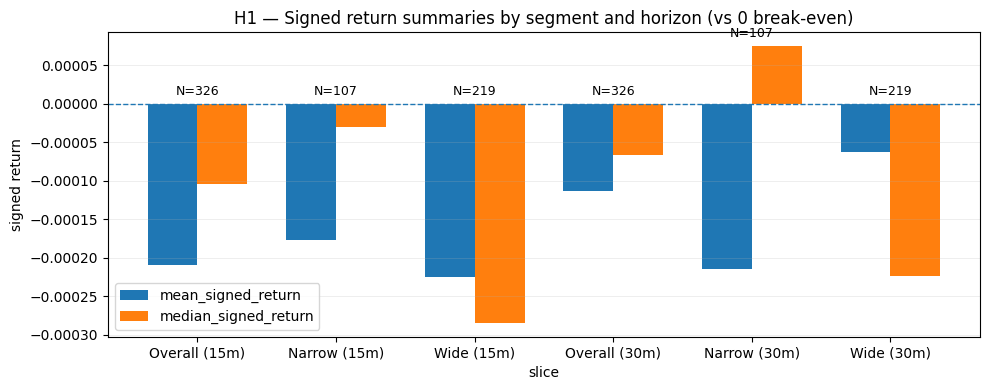

In [11]:
import matplotlib.pyplot as plt

# ==========================
# H1 — Plot #4
# Economic meaning: mean/median signed return (2 series) vs 0 break-even line
# ==========================

slices = ["overall_15", "narrow_15", "wide_15", "overall_30", "narrow_30", "wide_30"]

rows = []
for k in slices:
    if k not in h1:
        raise KeyError(f"Missing key in h1 JSON: {k}")
    block = h1[k]
    rows.append({
        "slice": k,
        "mean_signed_return": float(block.get("mean_signed_return", float("nan"))),
        "median_signed_return": float(block.get("median_signed_return", float("nan"))),
        "N": int(block.get("N", 0)),
    })

df_plot = pd.DataFrame(rows)

# labels + deterministic ordering
df_plot["segment"] = df_plot["slice"].str.split("_").str[0]
df_plot["horizon"] = df_plot["slice"].str.split("_").str[1].astype(int)
df_plot["label"] = df_plot["segment"].str.capitalize() + " (" + df_plot["horizon"].astype(str) + "m)"

seg_order = {"overall": 0, "narrow": 1, "wide": 2}
df_plot["seg_rank"] = df_plot["segment"].map(seg_order).fillna(99).astype(int)
df_plot = df_plot.sort_values(["horizon", "seg_rank"]).reset_index(drop=True)

# --- plot (single figure) ---
fig, ax = plt.subplots(figsize=(10, 4))

x = list(range(len(df_plot)))
w = 0.36

ax.bar([i - w/2 for i in x], df_plot["mean_signed_return"].values, width=w, label="mean_signed_return")
ax.bar([i + w/2 for i in x], df_plot["median_signed_return"].values, width=w, label="median_signed_return")

# break-even reference
ax.axhline(0.0, linewidth=1, linestyle="--")

ax.set_xticks(x)
ax.set_xticklabels(df_plot["label"].values)
ax.set_title("H1 — Signed return summaries by segment and horizon (vs 0 break-even)")
ax.set_ylabel("signed return")
ax.set_xlabel("slice")
ax.legend()

# annotate N slightly above the taller bar (or above 0 if both negative)
for i, (m, md, n) in enumerate(zip(df_plot["mean_signed_return"], df_plot["median_signed_return"], df_plot["N"])):
    y_top = max(m, md, 0.0)  # keep text readable when both bars are negative
    ax.text(i, y_top + (0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0]) if ax.get_ylim()[1] != ax.get_ylim()[0] else 0.01),
            f"N={n}", ha="center", va="bottom", fontsize=9)

ax.grid(True, axis="y", linewidth=0.6, alpha=0.25)
fig.tight_layout()
plt.show()


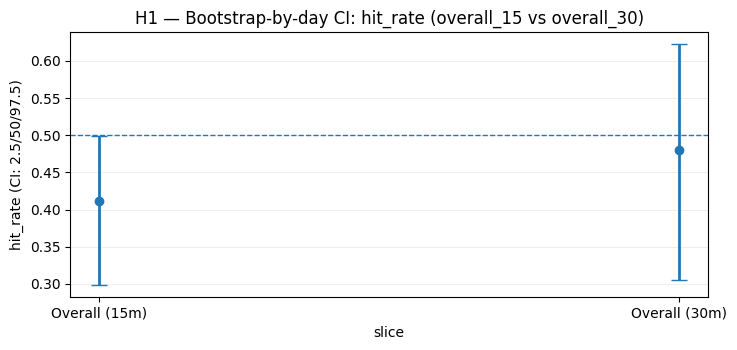

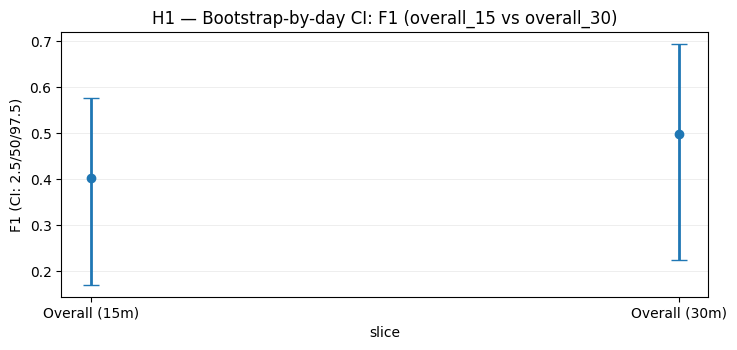

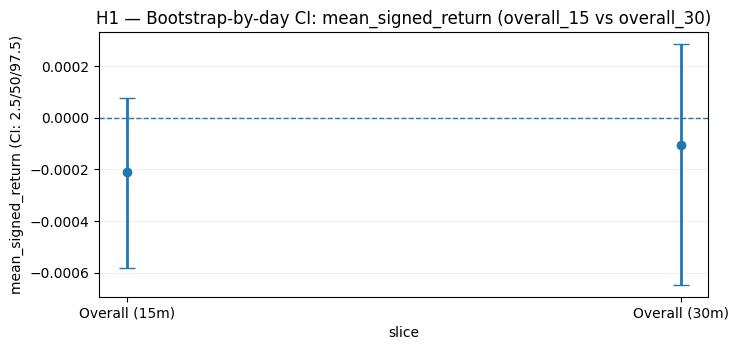

In [12]:
import matplotlib.pyplot as plt

# ==========================
# H1 — Plot #5/#6/#7 (Bootstrap-by-day CIs)
# hit_ci, f1_ci, mean_signed_return_ci
# overall_15 vs overall_30
# ==========================

b15 = h1.get("bootstrap_overall_15", None)
b30 = h1.get("bootstrap_overall_30", None)
if b15 is None or b30 is None:
    raise KeyError("Missing bootstrap blocks in h1: need 'bootstrap_overall_15' and 'bootstrap_overall_30'")

def _as_ci(block, key):
    arr = block.get(key, None)
    if not (isinstance(arr, list) and len(arr) == 3):
        raise KeyError(f"Bootstrap CI '{key}' missing or not a 3-list in block.")
    lo, mid, hi = map(float, arr)
    return lo, mid, hi

# Extract CIs
hit15 = _as_ci(b15, "hit_ci(2.5,50,97.5)")
hit30 = _as_ci(b30, "hit_ci(2.5,50,97.5)")

f115  = _as_ci(b15, "f1_ci(2.5,50,97.5)")
f130  = _as_ci(b30, "f1_ci(2.5,50,97.5)")

msr15 = _as_ci(b15, "mean_signed_return_ci(2.5,50,97.5)")
msr30 = _as_ci(b30, "mean_signed_return_ci(2.5,50,97.5)")

# Common x positions/labels
x = [0, 1]
labels = ["Overall (15m)", "Overall (30m)"]

def _plot_ci(ci15, ci30, title, ylabel, ref_y=None):
    fig, ax = plt.subplots(figsize=(7.5, 3.6))

    mids = [ci15[1], ci30[1]]
    yerr = [
        [mids[0] - ci15[0], mids[1] - ci30[0]],  # lower errors
        [ci15[2] - mids[0], ci30[2] - mids[1]],  # upper errors
    ]

    ax.errorbar(x, mids, yerr=yerr, fmt="o", capsize=6, linewidth=2)

    if ref_y is not None:
        ax.axhline(ref_y, linestyle="--", linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("slice")
    ax.grid(True, axis="y", linewidth=0.6, alpha=0.25)
    fig.tight_layout()
    plt.show()

# ---- Plot #5: hit-rate CI (vs 0.50) ----
_plot_ci(
    hit15, hit30,
    title="H1 — Bootstrap-by-day CI: hit_rate (overall_15 vs overall_30)",
    ylabel="hit_rate (CI: 2.5/50/97.5)",
    ref_y=0.50
)

# ---- Plot #6: F1 CI ----
_plot_ci(
    f115, f130,
    title="H1 — Bootstrap-by-day CI: F1 (overall_15 vs overall_30)",
    ylabel="F1 (CI: 2.5/50/97.5)",
    ref_y=None
)

# ---- Plot #7: mean signed return CI (vs 0) ----
_plot_ci(
    msr15, msr30,
    title="H1 — Bootstrap-by-day CI: mean_signed_return (overall_15 vs overall_30)",
    ylabel="mean_signed_return (CI: 2.5/50/97.5)",
    ref_y=0.0
)

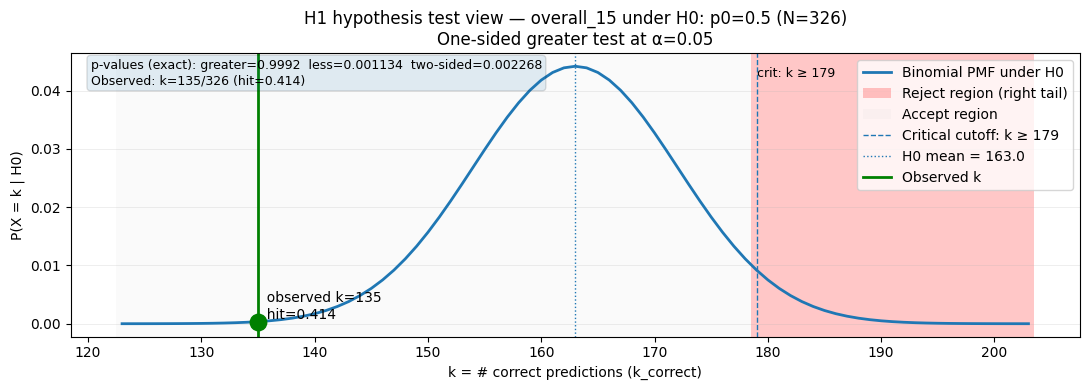

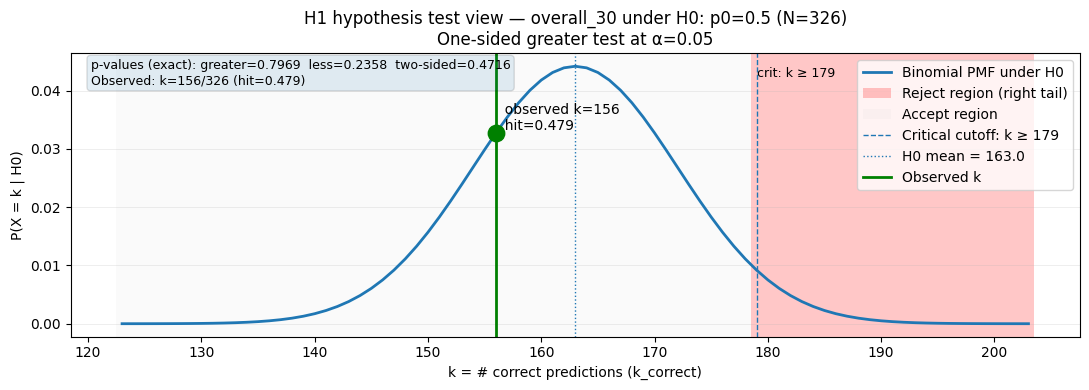

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# H1 — Reader-friendly hypothesis test view (Binomial under H0)
# ==========================


def _log_choose(n, k):
    return math.lgamma(n + 1) - math.lgamma(k + 1) - math.lgamma(n - k + 1)

def _binom_pmf(n, p0):
    ks = np.arange(n + 1)
    logpmf = np.array(
        [_log_choose(n, int(k)) + k * math.log(p0) + (n - k) * math.log(1 - p0) for k in ks],
        dtype=float
    )
    m = logpmf.max()
    pmf = np.exp(logpmf - m)
    pmf /= pmf.sum()
    return ks, pmf

def _cdf(pmf):
    return np.cumsum(pmf)

def _crit_two_sided(ks, pmf, alpha):
    c = _cdf(pmf)
    a2 = alpha / 2.0

    k_low = int(np.max(np.where(c <= a2)[0])) if np.any(c <= a2) else -1

    upper_tail = 1.0 - np.concatenate(([0.0], c[:-1]))  # P(X >= k)
    k_high = int(np.min(np.where(upper_tail <= a2)[0])) if np.any(upper_tail <= a2) else len(ks)

    return k_low, k_high

def _crit_greater(ks, pmf, alpha):
    c = _cdf(pmf)
    upper_tail = 1.0 - np.concatenate(([0.0], c[:-1]))
    k_g = int(np.min(np.where(upper_tail <= alpha)[0])) if np.any(upper_tail <= alpha) else len(ks)
    return k_g

def _pvals_exact(k_obs, pmf):
    c = _cdf(pmf)
    p_greater = float(1.0 - (c[k_obs - 1] if k_obs - 1 >= 0 else 0.0))
    p_less = float(c[k_obs])
    p_two = float(min(1.0, 2.0 * min(p_greater, p_less)))
    return p_greater, p_less, p_two

def plot_h1_test_readable(h1, key="overall_15", p0=0.5, alpha=0.05, mode="two-sided", window_sigmas=4):
    """
    mode:
      - "two-sided": left+right rejection (alpha/2 each), accept in the middle
      - "greater" : right-tail rejection only (alpha), accept on the left
    """
    if key not in h1:
        raise KeyError(f"Missing block: {key}")

    blk = h1[key]
    N = int(blk["N"])
    k_obs = int(blk["k_correct"])
    hit = float(blk["hit_rate"])

    ks, pmf = _binom_pmf(N, p0)
    mu = N * p0
    sigma = math.sqrt(N * p0 * (1 - p0))

    # critical values
    k_low, k_high = _crit_two_sided(ks, pmf, alpha)
    k_g = _crit_greater(ks, pmf, alpha)

    # choose a readable x-window around mean, but ensure it includes observed + criticals
    lo = max(0, int(math.floor(mu - window_sigmas * sigma)))
    hi = min(N, int(math.ceil(mu + window_sigmas * sigma)))

    include_vals = [k_obs, int(round(mu))]
    if k_low >= 0: include_vals.append(k_low)
    if k_high <= N: include_vals.append(k_high)
    if k_g <= N: include_vals.append(k_g)

    lo = max(0, min([lo] + include_vals) - 3)
    hi = min(N, max([hi] + include_vals) + 3)

    ks_w = ks[lo:hi + 1]
    pmf_w = pmf[lo:hi + 1]

    # pvals (exact)
    p_greater, p_less, p_two = _pvals_exact(k_obs, pmf)

    # --- plot ---
    fig, ax = plt.subplots(figsize=(11, 4))

    # neutral curve
    ax.plot(ks_w, pmf_w, linewidth=2, label="Binomial PMF under H0")

    # styling constants
    reject_alpha = 0.22
    accept_alpha = 0.10

    # Shade regions
    if mode == "two-sided":
        # reject left: k <= k_low
        if k_low >= lo:
            ax.axvspan(lo - 0.5, min(k_low, hi) + 0.5, alpha=reject_alpha, label="Reject region (left tail)")
        # reject right: k >= k_high
        if k_high <= hi:
            ax.axvspan(max(k_high, lo) - 0.5, hi + 0.5, alpha=reject_alpha, label="Reject region (right tail)")

        # accept middle
        a_lo = max(lo, k_low + 1)
        a_hi = min(hi, k_high - 1)
        if a_lo <= a_hi:
            ax.axvspan(a_lo - 0.5, a_hi + 0.5, alpha=accept_alpha, label="Accept region")

        # critical cut lines/labels
        if lo <= k_low <= hi:
            ax.axvline(k_low, linestyle="--", linewidth=1)
            ax.text(k_low, ax.get_ylim()[1]*0.95, f"k ≤ {k_low}", ha="right", va="top", fontsize=9)
        if lo <= k_high <= hi:
            ax.axvline(k_high, linestyle="--", linewidth=1)
            ax.text(k_high, ax.get_ylim()[1]*0.95, f"k ≥ {k_high}", ha="left", va="top", fontsize=9)

        subtitle = f"Two-sided test at α={alpha} (tails α/2 each)"
    elif mode == "greater":
        # reject right: k >= k_g
        if k_g <= hi:
            ax.axvspan(max(k_g, lo) - 0.5, hi + 0.5, alpha=reject_alpha, label="Reject region (right tail)")
        # accept left
        a_lo = lo
        a_hi = min(hi, k_g - 1)
        if a_lo <= a_hi:
            ax.axvspan(a_lo - 0.5, a_hi + 0.5, alpha=accept_alpha, label="Accept region")

        if lo <= k_g <= hi:
            ax.axvline(k_g, linestyle="--", linewidth=1, label=f"Critical cutoff: k ≥ {k_g}")
            ax.text(k_g, ax.get_ylim()[1]*0.95, f"crit: k ≥ {k_g}", ha="left", va="top", fontsize=9)

        subtitle = f"One-sided greater test at α={alpha}"
    else:
        raise ValueError("mode must be 'two-sided' or 'greater'")

    # Color the regions AFTER creating them by patch recoloring:
    # - rejection patches red
    # - accept patch light gray
    # We'll detect by their labels.
    for patch in ax.patches:
        lab = patch.get_label()
        if "Reject region" in lab:
            patch.set_facecolor("red")
        elif lab == "Accept region":
            patch.set_facecolor("lightgray")

    # H0 mean
    if lo <= mu <= hi:
        ax.axvline(mu, linestyle=":", linewidth=1, label=f"H0 mean = {mu:.1f}")

    # observed marker (GREEN)
    if lo <= k_obs <= hi:
        y_obs = pmf[k_obs]
        ax.axvline(k_obs, linewidth=2, color="green", label="Observed k")
        ax.scatter([k_obs], [y_obs], s=140, color="green", zorder=6)
        ax.text(k_obs, y_obs, f"  observed k={k_obs}\n  hit={hit:.3f}",
                ha="left", va="bottom", fontsize=10)

    # axes / grid / titles
    ax.set_title(f"H1 hypothesis test view — {key} under H0: p0={p0} (N={N})\n{subtitle}")
    ax.set_xlabel("k = # correct predictions (k_correct)")
    ax.set_ylabel("P(X = k | H0)")
    ax.grid(True, axis="y", linewidth=0.6, alpha=0.25)

    # info box (simple, readable)
    info = (
        f"p-values (exact): greater={p_greater:.4g}  less={p_less:.4g}  two-sided={p_two:.4g}\n"
        f"Observed: k={k_obs}/{N} (hit={hit:.3f})"
    )
    ax.text(0.02, 0.98, info, transform=ax.transAxes, va="top", ha="left", fontsize=9,
            bbox=dict(boxstyle="round", alpha=0.12))

    # Legend: keep it clean by deduping labels
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l)
            h2.append(h)
            l2.append(l)
    ax.legend(h2, l2, loc="upper right")

    fig.tight_layout()
    plt.show()

# --- Run examples ---
plot_h1_test_readable(h1, key="overall_15", p0=0.5, alpha=0.05, mode="greater", window_sigmas=4)

plot_h1_test_readable(h1, key="overall_30", p0=0.5, alpha=0.05, mode="greater", window_sigmas=4)
